Orbits Homework #3

In [2]:
# imports
import Orbits_Functions as of
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.integrate import solve_ivp

Perifocal

In [3]:
# 4.15

# constants
ecc = 1.5
r_earth = 6378 #km
mu = 398600 #km^3/s^2
rp = r_earth + 300 #km
inc  = np.deg2rad(35)
RAAN = np.deg2rad(130)
argp = np.deg2rad(115)

# part a
h = np.sqrt(mu*rp*(1+ecc))
vt_p = h/rp
r_p = np.array([[rp],
                [ 0],
                [ 0]])
v_p = np.array([[  0 ],
                [vt_p],
                [  0 ]])
print(f"Position at periapsis:\n{r_p}   km\nVelocity at periapsis:\n{v_p} km/s\n")

# part b
eci = of.COEs2ECI(h, ecc, inc, RAAN, argp, 0)
print(f"Position at periapsis:\n{eci[0]}   km\nVelocity at periapsis:\n{eci[1]} km/s\n")


Position at periapsis:
[[6678]
 [   0]
 [   0]]   km
Velocity at periapsis:
[[ 0.        ]
 [12.21561803]
 [ 0.        ]] km/s

Position at periapsis:
[-1983.77056575 -5348.76002148  3471.47008847]   km
Velocity at periapsis:
[10.35590353 -5.76267252 -2.96111316] km/s



Lamberts

In [4]:
# 5.6

# Use algorithm from curtis pg 244

# Constants
r1_vec = np.array([[5644, 2830, 4170]]) # km
r1 = np.linalg.norm(r1_vec)

r2_vec = np.array([[-2240, 7320, 4980]]) # km
r2 = np.linalg.norm(r2_vec)

dt = 20*60 # seconds

v1_vec, v2_vec, type, i = of.lamberts(r1_vec, r2_vec, dt, prograde=True, mu=398600)
print(np.linalg.norm(v1_vec), np.linalg.norm(v2_vec))
print(f'Velocity vector at state 1: {v1_vec} km/s\nVelocity vector at state 2: {v2_vec} km/s\nType of orbit: {type}\nCalculated in {i} iterations\n')

8.332953138079572 7.16751619970903
Velocity vector at state 1: [-4.8863863   6.02257165  3.04794482] km/s
Velocity vector at state 2: [-6.91678628  1.25491426 -1.39876597] km/s
Type of orbit: Elliptical
Calculated in 0 iterations



Transfers

In [5]:
# 6.8

# Constants
rearth = 6378
mu = 398600

# Orbit 1
rp1 = 300 + rearth
h1 = np.sqrt(mu*rp1)
vp1 = h1/rp1

# Orbit 2
rp2 = rp1
ra2 = 3000 + rearth
a2 = (rp2 + ra2)/2
ecc2 = (ra2-rp2)/(ra2+rp2)
h2 = np.sqrt(mu*rp2*(1+ecc2))
vp2 = h2/rp2
va2 = h2/ra2

# Orbit 3
rp3 = ra2
h3 = np.sqrt(mu*rp3)
vp3 = h3/rp3

# Final Calculations
delv_i = vp2-vp1
delv_f = vp3-va2

T2 = 2*np.pi*np.sqrt(a2**3/mu)
T_transfer = T2/2

delv_tot = abs(delv_i) + abs(delv_f)
print(f"The required change in velocity is {delv_tot} km/s")
print(f"The time it will take is {T_transfer/60} minutes")



The required change in velocity is 1.1977417046289824 km/s
The time it will take is 59.65419930364261 minutes


In [6]:
# 6.23

# Constants
mu = 398600
vb = np.deg2rad(45)
vc = np.deg2rad(150)

# Orbit 1
rp1 = 8100
ra1 = 18900
ecc1 = (ra1-rp1)/(rp1+ra1)
a1 = (rp1+ra1)/2
h1 = np.sqrt(mu*a1*(1-ecc1**2))
rb1 = (h1**2/mu)/(1+ecc1*(np.cos(vb)))
vb1 = np.sqrt(mu*(2/rb1-1/a1))
vrb1 = (mu/h1)*(ecc1*np.sin(vb))
vzb1 = (mu/h1)*(1+ecc1*np.cos(vb))

# Anomaly Calculations
Eb = 2*np.atan(np.sqrt((1-ecc1)/(1+ecc1))*np.tan(vb/2))
Mb = Eb - ecc1*np.sin(Eb)
Ec = 2*np.atan(np.sqrt((1-ecc1)/(1+ecc1))*np.tan(vc/2))
Mc = Ec - ecc1*np.sin(Ec)
dM = (Mc-Mb) % (2*np.pi)

dt1 = dM/np.sqrt(mu/a1**3)
T1 = 2*np.pi*np.sqrt(a1**3/mu)

# Orbit 2
T2 = T1 - dt1
rp2 = rb1
a2 = ((T2*np.sqrt(mu))/(2*np.pi))**(2/3)
ecc2 = 1 - rp2/a2
h2 = np.sqrt(mu*a2*(1-ecc2**2))
vp2 = h2/rp2

# Final Calulations
delv_1to2 = np.sqrt((0-vrb1)**2+(vp2-vzb1)**2)
delv_tot = 2*delv_1to2

print(f"The total change in velocity needed is {delv_tot} km/s")


The total change in velocity needed is 3.405352935296396 km/s


In [7]:
# 6.25

# Constants
mu = 398600
rearth = 6378
nub1 = np.deg2rad(100)

# Satellite Initial Trajectory
rp1 = 1270 + rearth
vp1 = 9
h1 = vp1 * rp1
a1 = (mu*rp1)/(2*mu-rp1*vp1**2)
ecc1 = 1 - rp1/a1
rb1 = (h1**2/mu)/(1+ecc1*np.cos(nub1))
vrb1 = (mu/h1)*ecc1*np.sin(nub1)
vzb1 = (mu/h1)*(1+ecc1*np.cos(nub1))

# Satellite Final Trajectory
rb2 = rb1
nub2 = nub1
ecc2 = .4
h2 = np.sqrt(((1+ecc2*np.cos(nub2))*h1**2)/(1+ecc1*np.cos(nub1)))
vrb2 = (mu/h2)*ecc2*np.sin(nub2)
vzb2 = (mu/h2)*(1+ecc2*np.cos(nub2))

# Final Calculations
delv = np.sqrt((vrb2-vrb1)**2 + (vzb2-vzb1)**2)

gamma1 = np.degrees(np.arctan2(vrb1, vzb1))
gamma2 = np.degrees(np.arctan2(vrb2, vzb2))
delgamma = gamma2 - gamma1

print(f"The required change in velocity is: {delv} km/s")
print(f"The change in flight path angle is: {delgamma} degrees")



The required change in velocity is: 0.9154526789887023 km/s
The change in flight path angle is: -8.181346964999939 degrees


In [8]:
# 6.31

# Constants
e = sp.Symbol("ecc", real=True)
rp1 = sp.Symbol("r_P1", real=True)
rp2 = sp.Symbol("r_P2", real=True)
h1 = sp.Symbol("h_1", real=True)
h2 = sp.Symbol("h_2", real=True)
mu = sp.Symbol("mu", real=True)

# Orbit 1
orbiteq = sp.Eq((h1**2/mu)/(1+e*(sp.cos(0))), (h2**2/mu)/(1))
ans1, ans2 = sp.solve(orbiteq, h2)

ans_final = sp.Eq(h2, sp.simplify(ans2))
display(ans_final)


Eq(h_2, h_1*sqrt(1/(ecc + 1)))

In [9]:
# 6.44

# Constants
mu = 398600
rearth = 6378
rp2 = 600 + rearth

# Part a

# Orbit 1
rp1 = 300 + rearth
inc1 = np.deg2rad(0)
ecc1 = 0
h1 = np.sqrt(mu*rp1)
vp1 = h1/rp1

# Hohmann Transfer
rpt = rp1
rat = rp2
ecct = (rat-rpt)/(rat+rpt)
at = (rat+rpt)/2
ht = np.sqrt(mu*rpt*(1+ecct*np.cos(0)))
vpt = ht/rpt
vat = ht/rat

# Orbit 1 with increased radius
inc2 = np.deg2rad(20)
ecc2 = 0
h2 = np.sqrt(mu*rp2)
vp2 = h2/rp2

# Inclination change
delvi = 2*vp2*np.sin((inc2-inc1)/2)

# Part a Final Calculations
delv1 = vpt - vp1
delv2 = vp2 - vat
delv_tot_a = abs(delv1) + abs(delv2) + abs(delvi)
print(delv_tot_a)


# Part b

# Orbit 1
vr1 = 0
vz1 = vp1

# Beginning of hohmann transfer
# uses delv1

# Inc change and circularizing
delvt = np.sqrt(vat**2 + vp2**2 - 2*vat*vp2*np.cos(inc2-inc1))

# Part c Final Calculations
delv_tot_b = abs(delv1) + abs(delvt)
print(delv_tot_b)

# Part c

# Hohmann and inc transfer orbit
vrt = 0
delvt = np.sqrt(vz1**2 + vpt**2 - 2*vz1*vpt*np.cos(inc2-inc1))

# Part b Final Calculations
delv_tot_c = abs(delvt) + abs(delv2)
print(delv_tot_c)


2.7927230793198623
2.696042636174117
2.78256936848282


10621.17966771773


c:\Users\hlflu\OneDrive - Cal Poly\Desktop\Python\VScode\AERO351\.venv_AERO351\Lib\site-packages\pyvista\jupyter\notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


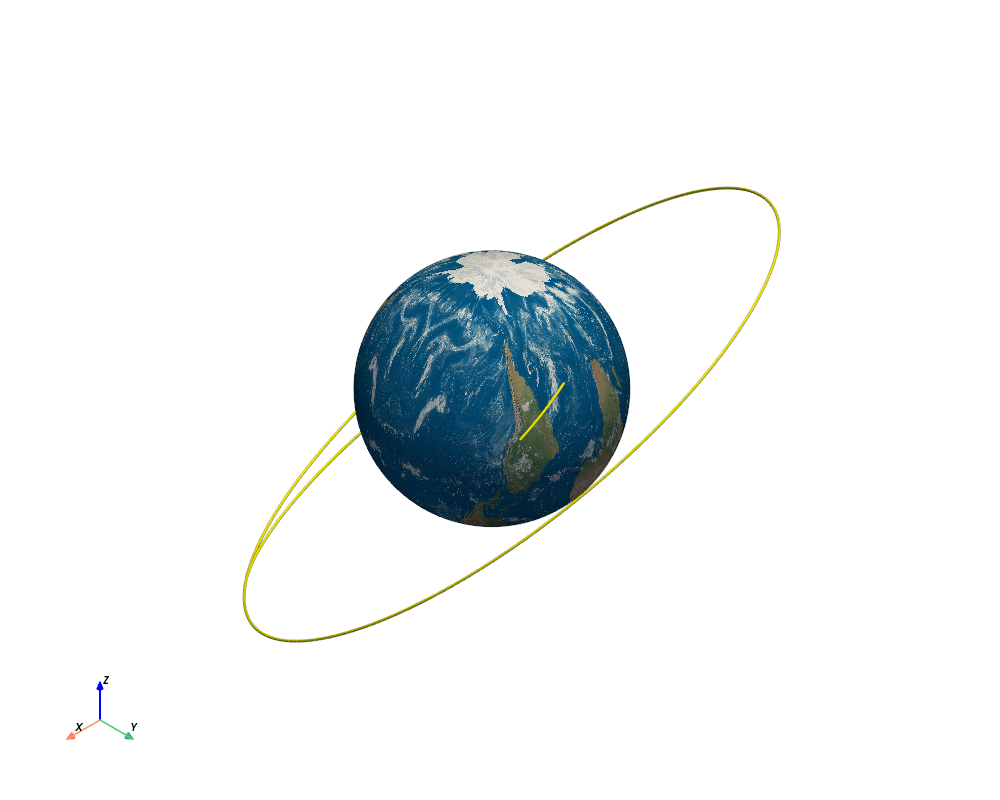

Total time from t0 to apoapsis: 10850.65387661969 s (3.014070521283247 min)


In [10]:
# 6.47

# Constants
mu = 398600
rearth = 6378
Ft = 10000
Isp = 300
g = 9.81
t1 = 89*60
tburn = 120
tspan_idle = [0, t1]
tspan_burn = [0, tburn]
mdot = Ft/(Isp*g)

# Initial State
r0 = np.array([4361, 6083, 2529])
v0 = np.array([-7.34, -0.5125, 2.497])
m0 = 1000

# Integrate Idle
sol_idle = of.ODEprimer(r0, v0, tspan_idle)
r1 = sol_idle.y[0:3,-1]
v1 = sol_idle.y[3:6,-1]

def burn_integral(t, y):
    r = y[:3]
    v = y[3:6]
    m = y[6]
    rn = np.linalg.norm(r)
    vn = np.linalg.norm(v)
    accel_g = -mu*r/rn**3
    accel_t = (Ft/m)/1000*(v/vn)
    dm = -mdot
    return np.hstack((v, accel_g+accel_t, dm))

y0 = np.hstack((r1, v1, m0))
sol_burn = solve_ivp(lambda t, y: burn_integral(t, y), tspan_burn, y0, rtol=1e-8, atol=1e-9)
r2_vec = sol_burn.y[:3, -1]
r2 = np.linalg.norm(r2_vec)
v2_vec = sol_burn.y[3:6, -1]
v2 = np.linalg.norm(v2_vec)
h2 = np.linalg.norm(np.cross(r2_vec, v2_vec))
energy = v2**2/2 - mu/r2
a = -mu/(2*energy)
ecc2 = np.sqrt(1-h2**2/(a*mu))
ra2 = a*(1+ecc2)
print(ra2-6378)

def coast_integral(t, y):
    r = y[:3]
    v = y[3:6]
    rn = np.linalg.norm(r)
    accel = -mu * r / rn**3
    return np.hstack((v, accel))

def apoapsis(t, y):
    r = y[:3]
    v = y[3:6]
    return np.dot(r, v) / np.linalg.norm(r)
apoapsis.direction = -1

y_coast0 = np.hstack((r2_vec, v2_vec))

sol_coast = solve_ivp(lambda t, y: coast_integral(t, y), (0, 20000), y_coast0, events=apoapsis, rtol=1e-9, atol=1e-12)

from types import SimpleNamespace
burn_pos  = SimpleNamespace(y=sol_burn.y[:3, :])   # 3xN
coast_pos = SimpleNamespace(y=sol_coast.y[:3, :])
of.plot_orbit(
    [sol_idle, burn_pos, coast_pos],
    label=["Idle", "Burn", "Coast"]
)


e_vec = np.cross(v2_vec, np.cross(r2_vec, v2_vec))/mu - r2_vec/r2
e = np.linalg.norm(e_vec)
# true anomaly at cutoff
nu0 = np.arccos((a*(1 - e**2)/r2 - 1)/e)
if np.dot(r2_vec, v2_vec) < 0:
    nu0 = 2*np.pi - nu0
E0 = 2*np.arctan2(np.tan(nu0/2)*np.sqrt(1 - e), np.sqrt(1 + e))
Ea = np.pi
n = np.sqrt(mu / a**3)
dM = Ea - e*np.sin(Ea) - (E0 - e*np.sin(E0))
t_coast_to_apo = dM / n

t_total_from_t0 = t1 + tburn + t_coast_to_apo
print(f"Total time from t0 to apoapsis: {t_total_from_t0} s ({t_total_from_t0/(60*60)} min)")